# Demonstration of rotationally symmetric SVD decomposition in Panther-EM.

1. Download and simulate cryo-EM projections of a structure
2. Perform optimized SVD decomposition by exploiting in-plane rotational symmetry (in polar coordinates)
3. Plot singular values of the decomposition
4. Plot polar/cartesian features of decomposition

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from torch_so3 import get_uniform_euler_angles
from ttsim3d.models import Simulator, SimulatorConfig

from panther_em.decomposition import PolarProjectionDecomposer
from panther_em.inference.projection_reconstruction import ProjectionReconstructor

## Load in volume to take projections from

In [2]:
!wget -nc https://files.rcsb.org/download/pdb_00007myi.cif

File ‘pdb_00007myi.cif’ already there; not retrieving.



In [3]:
pdb_path = "pdb_00007myi.cif"

In [4]:
# Instantiate the configuration object
sim_conf = SimulatorConfig(
    voltage=300.0,  # in keV
    apply_dose_weighting=True,
    dose_start=0.0,  # in e-/A^2
    dose_end=15.0,  # in e-/A^2
    upsampling=-1,  # auto
)

# Instantiate the simulator
sim = Simulator(
    pdb_filepath=pdb_path,
    pixel_spacing=0.4,  # Angstroms
    volume_shape=(512, 512, 512),
    b_factor_scaling=1.0,
    additional_b_factor=30.0,
    simulator_config=sim_conf,
)

In [5]:
# Run the simulation
volume = sim.run()
print(type(volume))
print(volume.shape)

/home/mgiammar/git_repositories/Panther-EM/.venv/lib/python3.12/site-packages/ttsim3d/simulate3d.py:50: FutureWarning: This function is deprecated and will be removed in a future version. Please use torch_ctf.calculate_relativistic_electron_wavelength instead.
  wavelength_m = calculate_relativistic_electron_wavelength(beam_energy_ev)


<class 'torch.Tensor'>
torch.Size([512, 512, 512])


In [6]:
# import mrcfile

# # NOTE: Or load in pre-computed volume from elsewhere
# volume_path = "/data/mgiammar/MOSAICS/data/volumes/parsed_6Q8Y_whole_LSU_match3.mrc"
# volume = mrcfile.read(volume_path).data.copy()
# volume = torch.from_numpy(volume).float()
# print(type(volume))
# print(volume.shape)

In [7]:
volume = volume.numpy()

## Define the out-of-plane orientations

Using `torch-so3` to approximate points over SO(3) space, except all in-plane angles are set to zero.

In [8]:
angles = get_uniform_euler_angles(psi_step=360.0, theta_step=6.0)
print(angles.shape)

phi_angles = angles[:, 0].numpy()
theta_angles = angles[:, 1].numpy()

torch.Size([1148, 3])


## Run the decomposition

In [9]:
radial_components = 256
angular_components = 360

decomposer = PolarProjectionDecomposer(
    volume=volume,
    phi_values=phi_angles,
    theta_values=theta_angles,
    device="cuda",
    num_radius=radial_components,
    num_angle=angular_components,
)

result = decomposer.do_decomposition()

decomp freq blocks: 100%|██████████| 45/45 [00:03<00:00, 11.40it/s]


In [10]:
result

DecompositionResult(num_fourier_filters=1, num_orientations=1148, num_angular_components=360, num_radial_components=256, k_max=360, created_at='2026-04-04T16:02:30.578736')

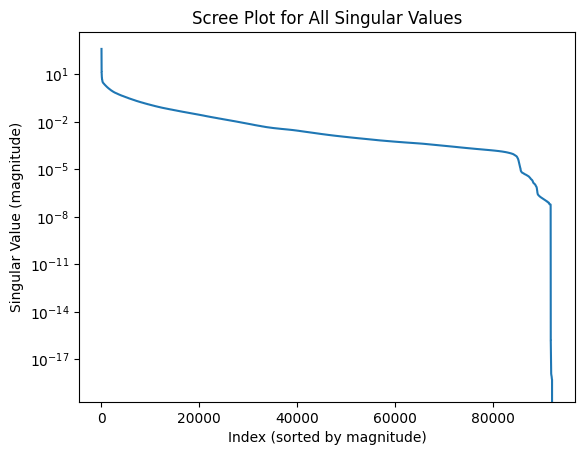

In [12]:
fix, ax = result.scree_plot()
plt.yscale("log")

## Visualize real/imag feature components in polar and cartesian space

In [14]:
reconstructor = ProjectionReconstructor(
    result=result,
    image_shape=(volume.shape[-2], volume.shape[-1]),
    device="cuda",
)

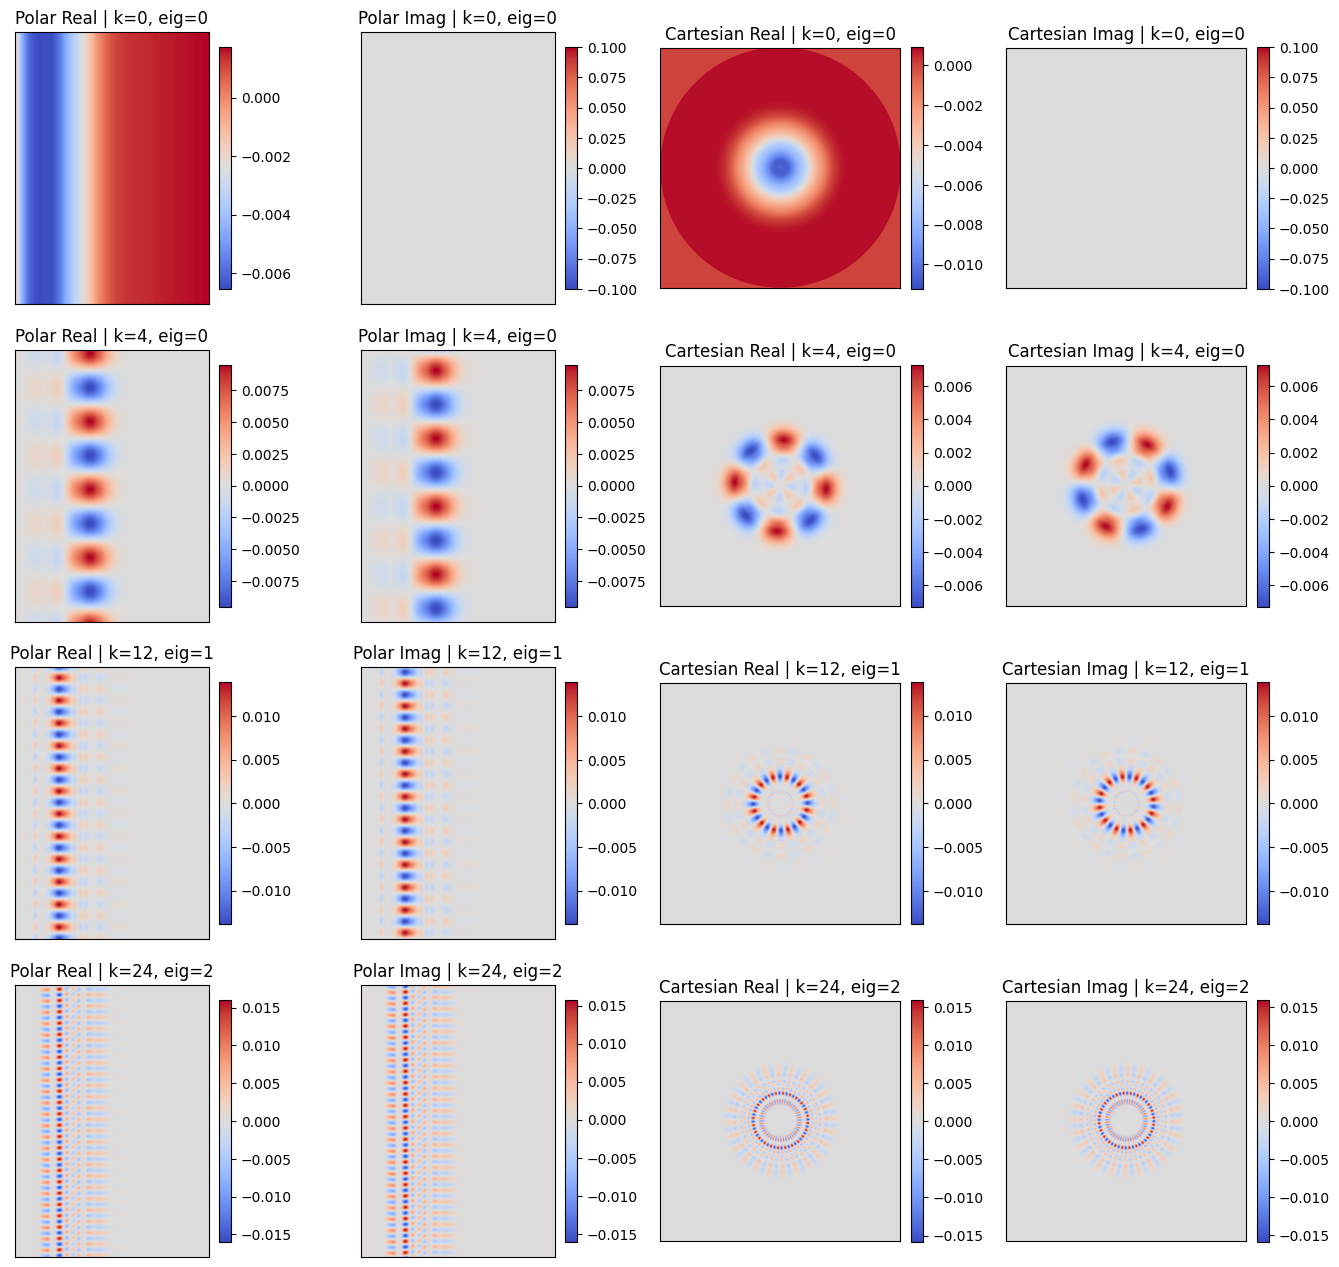

In [15]:
# Pick a few (k_idx, eig_idx) feature pairs to inspect
feature_pairs = [(0, 0), (4, 0), (12, 1), (24, 2)]

n = len(feature_pairs)
fig, axes = plt.subplots(n, 4, figsize=(14, 3.2 * n), squeeze=False)

for row, (k_idx, eig_idx) in enumerate(feature_pairs):
    polar_feature = reconstructor.construct_polar_feature(k_idx=k_idx, eig_idx=eig_idx)
    cart_feature = reconstructor.construct_cartesian_feature(
        k_idx=k_idx, eig_idx=eig_idx
    )

    panels = [
        (np.real(polar_feature), "Polar Real"),
        (np.imag(polar_feature), "Polar Imag"),
        (np.real(cart_feature), "Cartesian Real"),
        (np.imag(cart_feature), "Cartesian Imag"),
    ]

    for col, (img, title) in enumerate(panels):
        ax = axes[row, col]
        im = ax.imshow(img, cmap="coolwarm")
        ax.set_title(f"{title} | k={k_idx}, eig={eig_idx}")
        ax.set_xticks([])
        ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()